# 5조 Big5 최종 코드

## 1. 데이터 준비
프로젝트에 필요한 라이브러리 및 데이터 경로를 설정하고, 랜덤 시드를 고정하여 실험의 재현성을 확보합니다.

### 1-1. 라이브러리 import 및 데이터 경로 정의
모델 학습과 추론에 필요한 라이브러리들을 불러오고, 데이터셋이 위치한 경로를 정의합니다.

In [1]:
import os
import glob
import math
import random
import pandas as pd
import numpy as np
import copy
from tqdm import tqdm
from PIL import Image

# data analysis
import matplotlib.pyplot as plt
import seaborn as sns

# model
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models
from sklearn.metrics import f1_score

# path
TRAIN_DIR = "/test/final_exam/challenge/train"
TEST_DIR  = "/test/final_exam/challenge/test"
LABEL_CSV = "label_info.csv"
sample_submission_csv = "sample_submission.csv"
# output_csv= "./submission_single_resnet18_Big5_maybefinal.csv"
output_csv= "./final_test_1_epoch.csv"

### 1-2. Random Seed 고정
재현성을 위해 실험에 사용되는 모든 난수를 고정합니다.

In [2]:
def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## 2. 데이터 분석

실험에 앞서, 데이터의 전반적인 형태와 분포를 확인하고 데이터셋을 이해하기 위해 분석 작업을 수행했습니다.

### 2-1. 전체 데이터 분석
각 label마다 몇 개의 데이터가 존재하는지 시각화하여 전체 데이터의 분포를 확인했습니다.

/tmp/ipykernel_262417/1894012696.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='label', data=class_counts, palette='viridis')


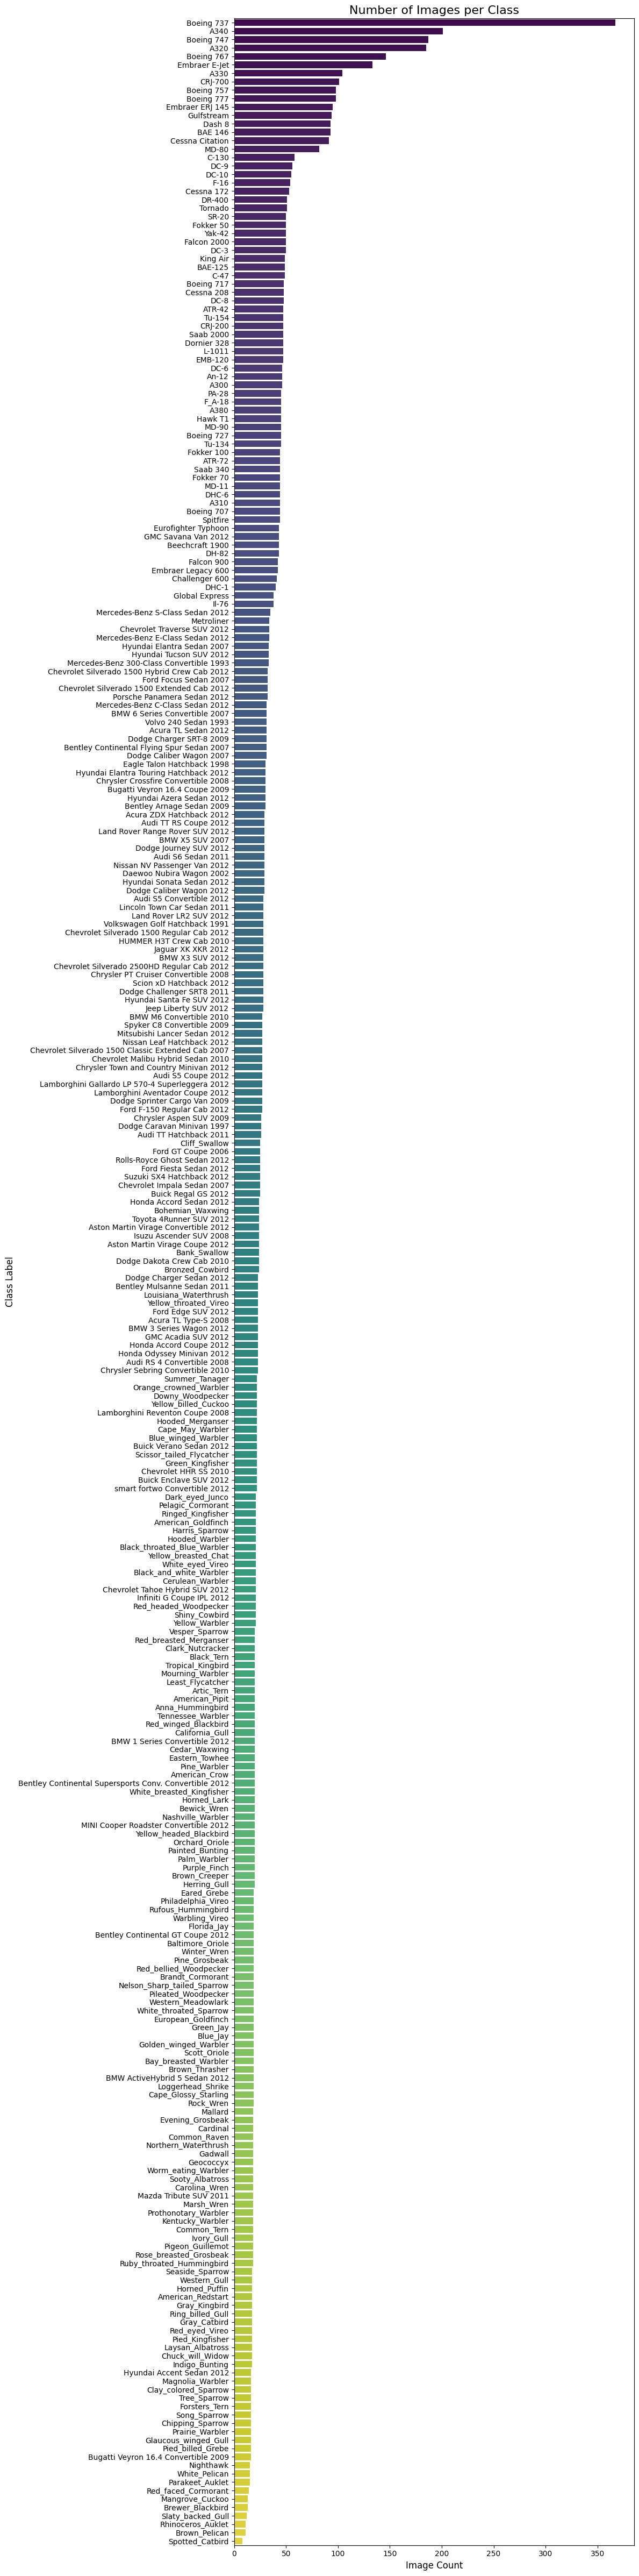

In [3]:
rows = []

for class_name in os.listdir(TRAIN_DIR):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue

    for filename in os.listdir(class_dir):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            filepath = os.path.join(class_dir, filename)
            rows.append({
                'filepath': filepath,
                'label': class_name
            })

df = pd.DataFrame(rows)

# 클래스별 이미지 수 계산
class_counts = df['label'].value_counts().reset_index()
class_counts.columns = ['label', 'count']

output_folder = "visual"
os.makedirs(output_folder, exist_ok=True) 

plt.figure(figsize=(12, 48))
sns.barplot(x='count', y='label', data=class_counts, palette='viridis')
plt.title('Number of Images per Class', fontsize=16)
plt.xlabel('Image Count', fontsize=12)
plt.ylabel('Class Label', fontsize=12)
plt.tight_layout()
plt.show()

### 2-2. group 별 데이터 분석
각 그룹마다 몇 개의 데이터가 존재하는지 시각화하여 그룹별 데이터의 분포도 확인했습니다.

/tmp/ipykernel_262417/2822679298.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='group', y='count', data=grouped_counts, palette='viridis')


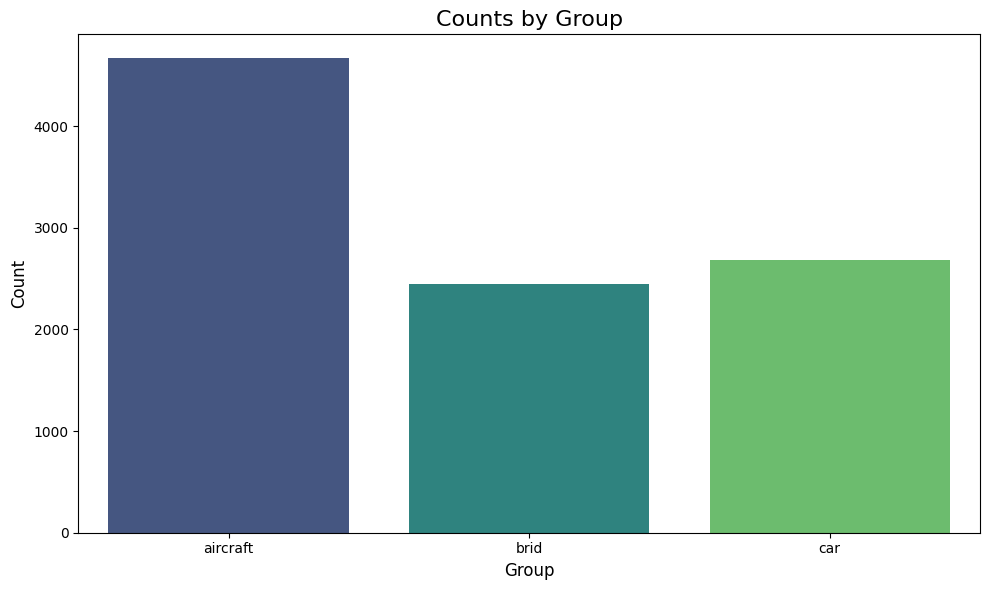

In [4]:
# 1) 3 그룹 별 개수 확인

count_df = df['label'].value_counts()
count_df = count_df.reset_index()
count_df.columns = ['label', 'count']
label_info_df = pd.read_csv(LABEL_CSV)

merged_df = pd.merge(count_df, label_info_df, on='label', how='left')

grouped_counts = merged_df.groupby('group')['count'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='group', y='count', data=grouped_counts, palette='viridis')
plt.title('Counts by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

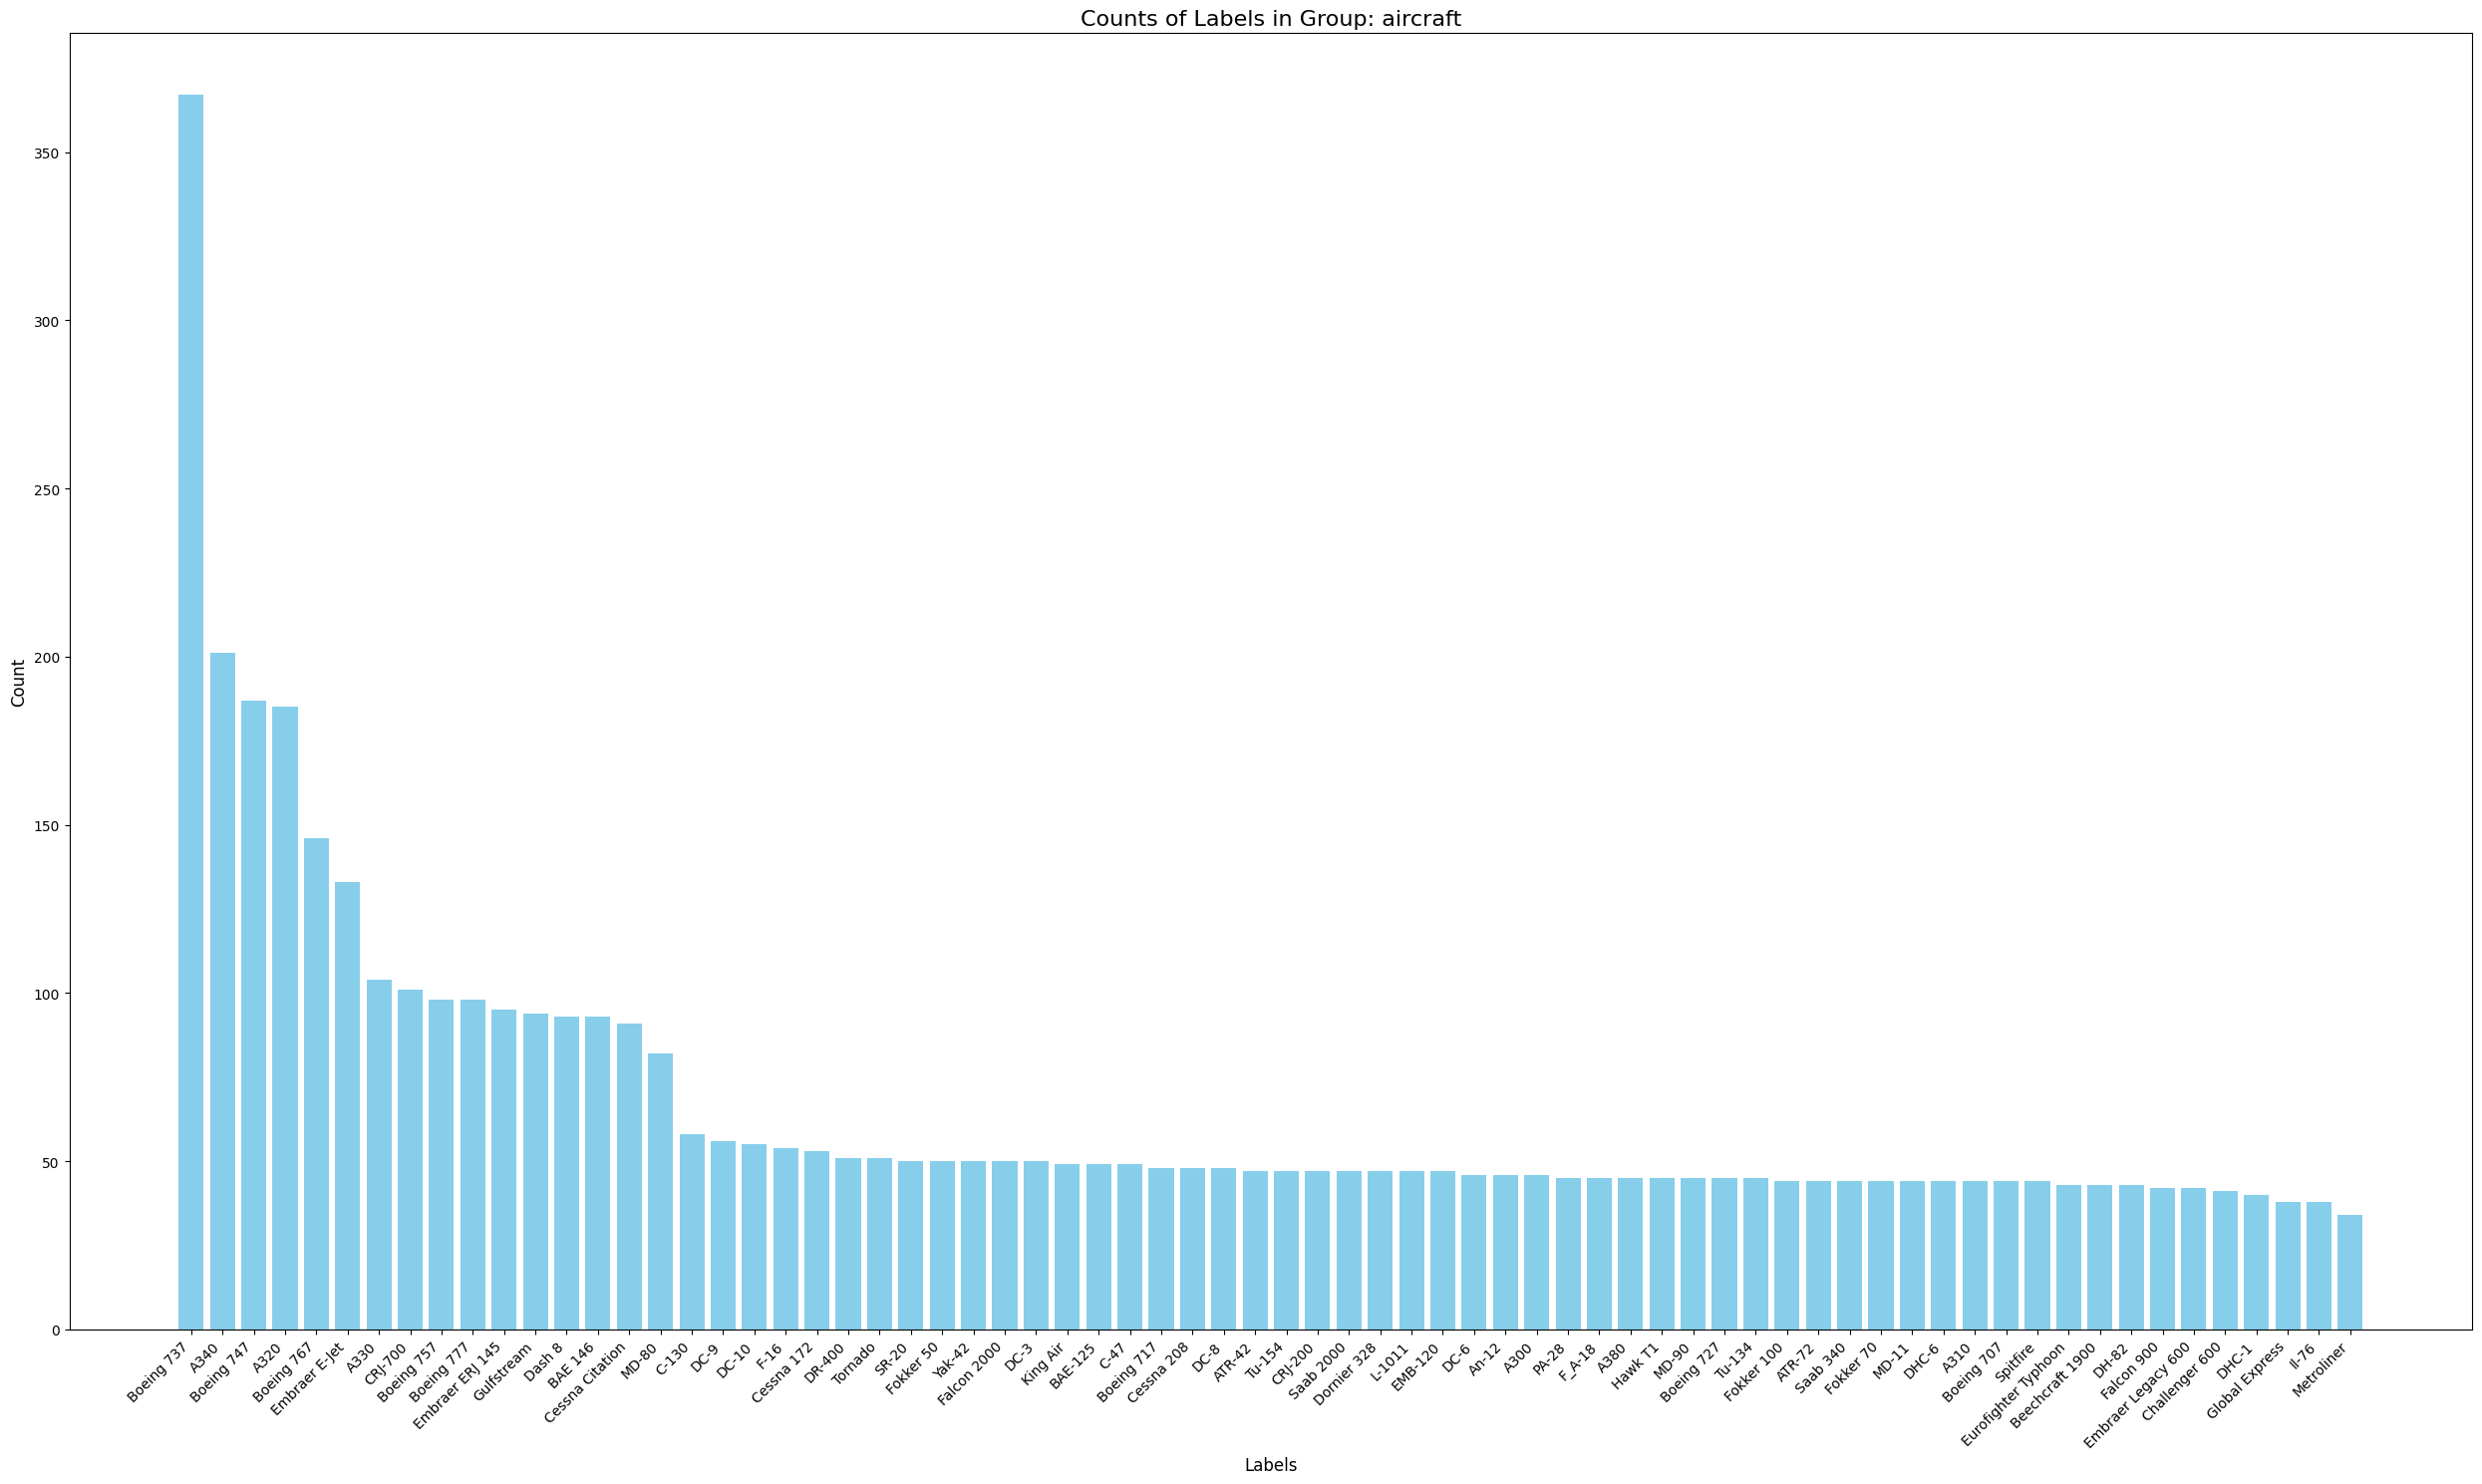

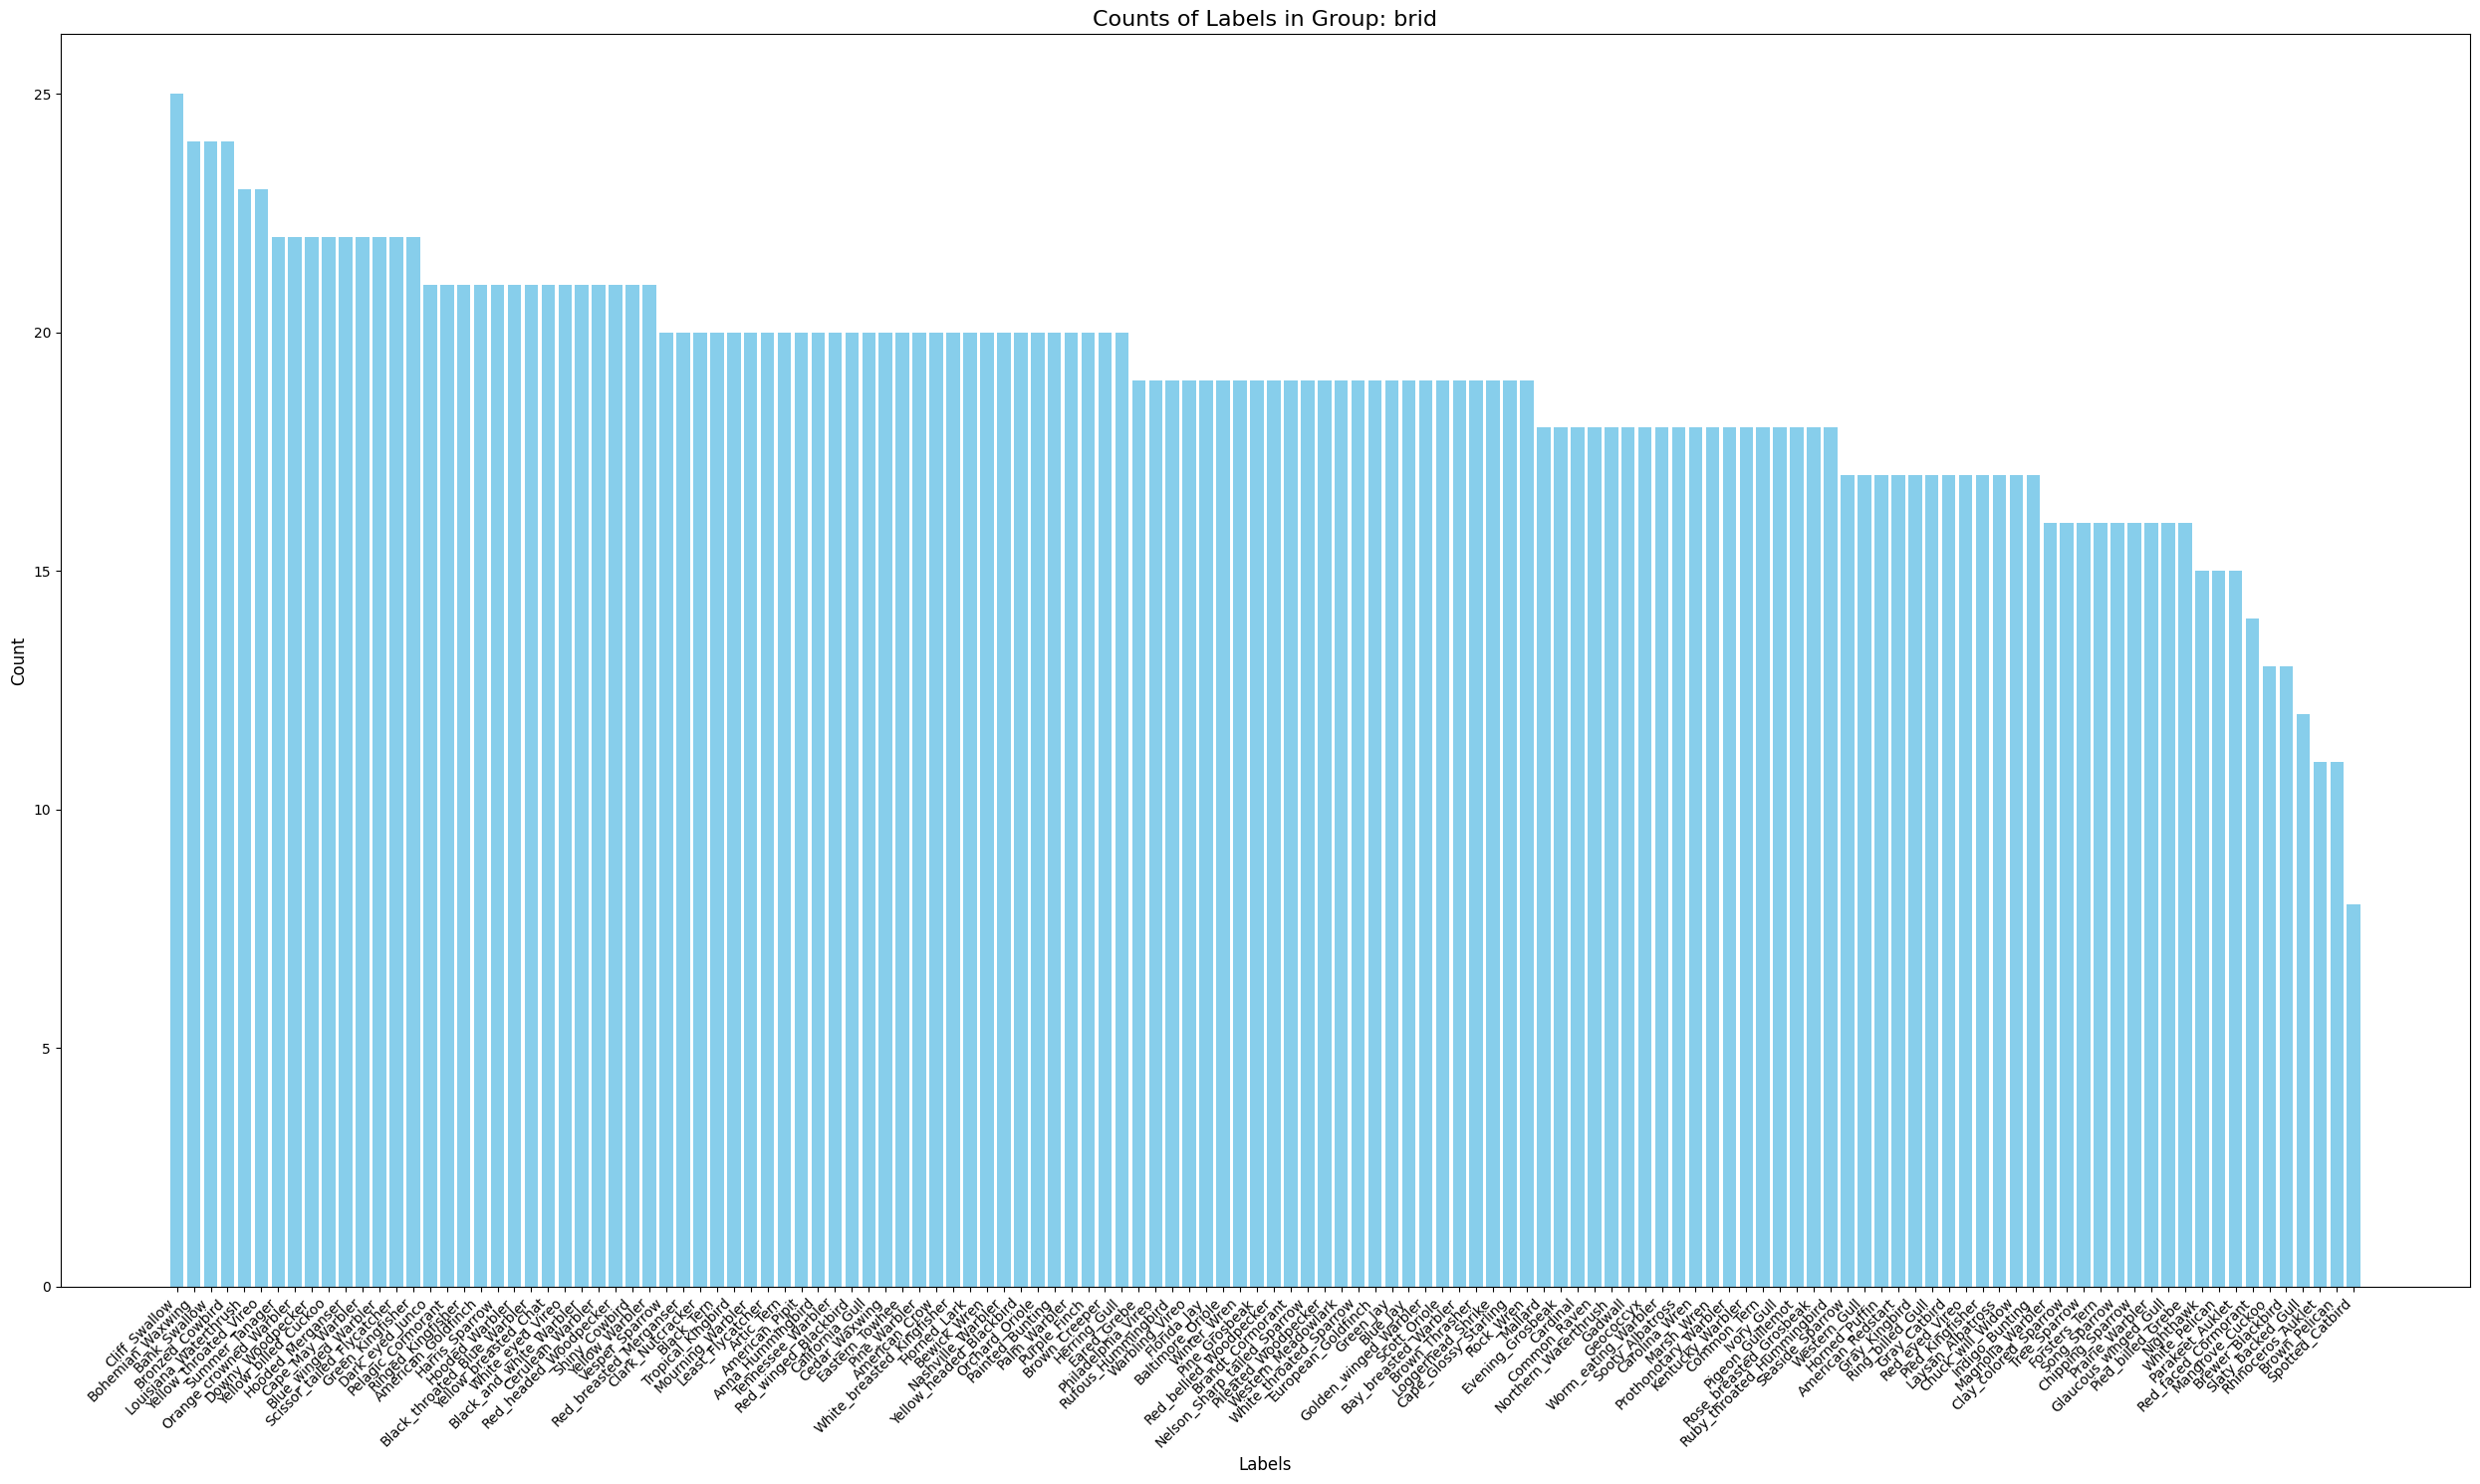

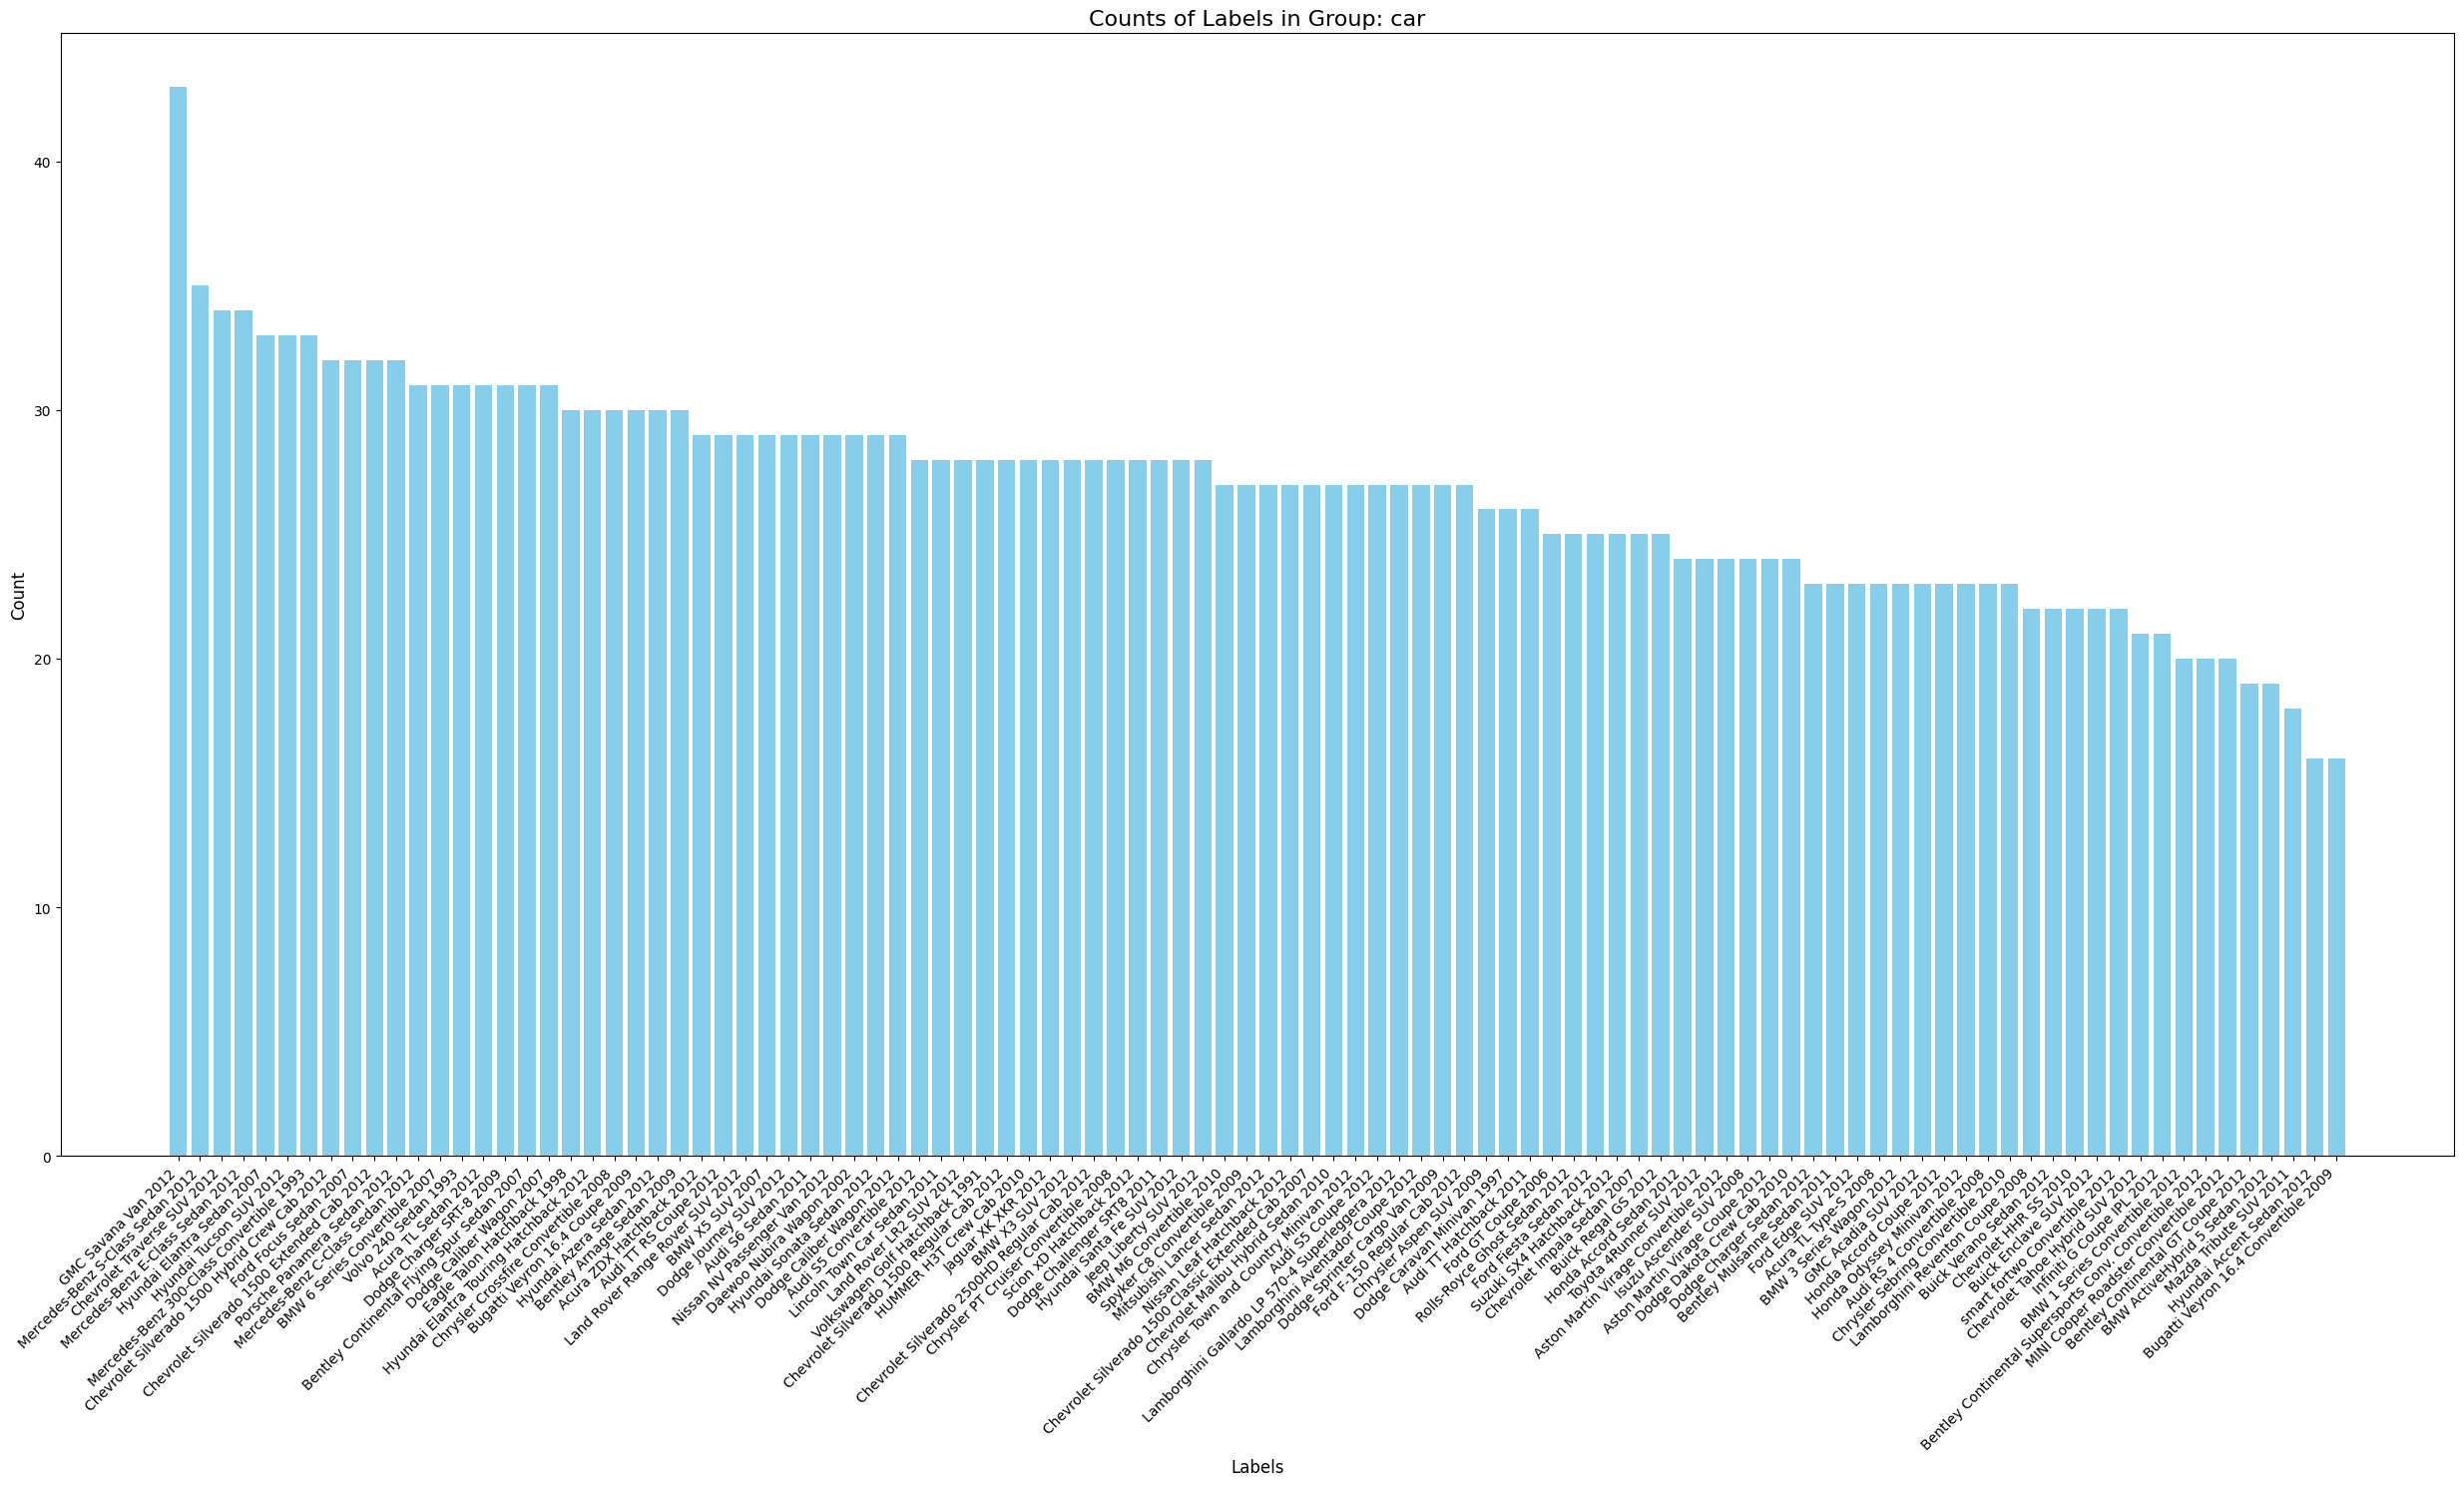

In [5]:
# 2) 각 그룹별 클래스 개수 확인

merged_df = pd.merge(count_df, label_info_df, on='label', how='left')

grouped = merged_df.groupby('group')

output_folder = "visual"
os.makedirs(output_folder, exist_ok=True)

# 각 그룹마다 plot 생성
for group_name, group_data in grouped:
    plt.figure(figsize=(25, 15))
    plt.bar(group_data['label'], group_data['count'], color='skyblue')
    plt.title(f'Counts of Labels in Group: {group_name}', fontsize=16)
    plt.xlabel('Labels', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 3. 데이터 전처리
데이터 분석 결과에 기반하여, 데이터 품질을 높이고 클래스 불균형을 해소하기 위해 다양한 증강 및 오버샘플링 기법을 적용합니다.

- **새, 자동차**의 경우 상대적으로 부족한 데이터를 보완하기 위해 추가적인 증강 수행
- **비행기**는 기본적인 Resize 처리만 적용
- 데이터 구조를 기반으로 **직접 라벨링**하여 데이터셋 구성
- **오버샘플링**을 통해 클래스 간 데이터 불균형을 완화

### 3-1. 데이터 증강 및 라벨링
각 클래스(새, 자동차, 비행기) 별로 다른 변환(Transform)을 적용하기 위해, CustomImageFolder를 구현하여 데이터를 불러옵니다.

In [6]:
# 1) 데이터 증강 기법 정의

# 새와 자동차에는 RandomHorizontalFlip, RandomRotation 등을 적용
aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor()
])
# 비행기에는 기본 변환만 적용
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

**CustomImageFolder**
- `ImageFolder` 클래스를 상속하여, `label_info.csv`를 통해 불러온 라벨-그룹 정보를 사용
- 그룹(새, 자동차, 비행기)에 따라 서로 다른 `transform`을 적용

In [7]:
# 2) train 데이터 새, 비행기, 자동차 라벨링

class CustomImageFolder(ImageFolder):
    def __init__(self, root, label_info_csv, transform_dict=None):
        super().__init__(root=root, transform=None)
        self.df_label_info = pd.read_csv(label_info_csv)
        self.label_to_group = dict(zip(
            self.df_label_info["label"],
            self.df_label_info["group"]
        ))
        self.transform_dict = transform_dict if transform_dict else {}

    def __getitem__(self, index):
        path, class_idx = self.samples[index]
        class_name = self.classes[class_idx]
        # label_info.csv의 group 칼럼을 통해 클래스에 해당하는 그룹 이름(새, 자동차, 비행기) 확인
        group_name = self.label_to_group.get(class_name, None)

        image = self.loader(path)

        # 그룹별로 정의된 transform을 적용
        transform_to_apply = self.transform_dict.get(group_name, None)
        if transform_to_apply is not None:
            image = transform_to_apply(image)

        return image, class_idx

**transform_dict**를 활용해 `CustomImageFolder`를 생성하고, 클래스마다 서로 다른 증강 기법을 적용합니다.

In [8]:
# 3) 데이터 불러오기
transform_dict = {
    "brid": aug_transform,  # 새
    "car": aug_transform,   # 자동차
    "aircraft": basic_transform  # 비행기
}

custom_dataset = CustomImageFolder(
    root=TRAIN_DIR,
    label_info_csv=LABEL_CSV,
    transform_dict=transform_dict
)

### 3-2. 불균형 데이터 오버샘플링
클래스 불균형 문제를 완화하기 위해, 부족한 클래스를 오버샘플링하여 각 클래스의 샘플 수를 동일하게 맞춥니다.

In [9]:
# 1) 오버샘플링 정의
def get_group_indices(dataset):
    bird_indices = []
    car_indices = []
    aircraft_indices = []
    for i, (path, class_idx) in enumerate(dataset.samples):
        class_name = dataset.classes[class_idx]
        group_name = dataset.label_to_group.get(class_name, None)
        if group_name == "brid":
            bird_indices.append(i)
        elif group_name == "car":
            car_indices.append(i)
        elif group_name == "aircraft":
            aircraft_indices.append(i)
    return bird_indices, car_indices, aircraft_indices

bird_indices, car_indices, aircraft_indices = get_group_indices(custom_dataset)

bird_dataset = Subset(custom_dataset, bird_indices)
car_dataset  = Subset(custom_dataset, car_indices)
aircraft_dataset = Subset(custom_dataset, aircraft_indices)

print("[oversampling 전]")
print(len(bird_dataset), len(car_dataset), len(aircraft_dataset))

def oversample_to_size(dataset, target_size):
    current_size = len(dataset)
    if current_size >= target_size:
        return dataset
    
    # 부족한 데이터를 여러 번 복제하여 가장 많은 비행기 데이터의 개수(4669)에 맞게 채움
    replication_factor = math.ceil(target_size / current_size)
    repeated_dataset = ConcatDataset([dataset] * replication_factor)

    indices = list(range(len(repeated_dataset)))
    random.shuffle(indices)
    chosen_indices = indices[:target_size]
    oversampled_subset = Subset(repeated_dataset, chosen_indices)
    return oversampled_subset

target_size = len(aircraft_dataset)
bird_dataset_oversampled = oversample_to_size(bird_dataset, target_size)
car_dataset_oversampled  = oversample_to_size(car_dataset,  target_size)

print("[oversampling 후]")
print(len(bird_dataset_oversampled), len(car_dataset_oversampled), len(aircraft_dataset))

[oversampling 전]
2450 2678 4669
[oversampling 후]
4669 4669 4669


오버샘플링된 **bird_dataset_oversampled**, **car_dataset_oversampled**, **aircraft_dataset**를 합쳐 최종 **train_dataset**을 구성합니다.

In [10]:
# 2) 최종 dataloader 정의
BATCH_SIZE = 64

combined_dataset = ConcatDataset([
    bird_dataset_oversampled,
    car_dataset_oversampled,
    aircraft_dataset
])

train_dataset = combined_dataset
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

## 4. 모델링

### 4-1. 라벨 스무딩 함수 정의
- 분류해야 할 클래스가 총 300개로 많은 편이기 때문에, label smoothing 기법을 활용했습니다.
- 과적합을 완화하고, 어느 정도 정규화함으로써 모델을 조금 더 일반화하는 효과를 주기 위해 사용했습니다.

In [11]:
MODEL_NAMES = [f"resnet18_{i}" for i in range(1, 7)]

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -log_probs.mean(dim=-1)
        loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

def build_model(model_name, num_classes=300):
    if model_name.startswith("resnet18"):
        model = models.resnet18(pretrained=False)
        in_feats = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_feats, num_classes)
        )
    return model

### 4-2. 모델 및 학습 파라미터 설정

In [13]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = 300

LR = 0.001
EPOCHS = 70
LABEL_SMOOTHING = 0.1
DROPOUT_PROB = 0.3
NUM_WORKERS = 0 

### 4-3. Train 함수 정의
Resnet18

In [14]:
def train_one_epoch(model, criterion, optimizer, train_loader):
    model.train()
    running_loss = 0.0
    total = 0
    preds_list = []
    labels_list = []

    for images, labels in tqdm(train_loader, desc="Train", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        preds_list.extend(preds.detach().cpu().numpy())
        labels_list.extend(labels.detach().cpu().numpy())
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_f1   = f1_score(labels_list, preds_list, average='macro')
    return epoch_loss, epoch_f1

In [15]:
def train(model_name, train_loader, epochs=EPOCHS, lr=LR, early_stopping_patience=10):
    model = build_model(model_name, num_classes=NUM_CLASSES).to(DEVICE)

    criterion = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTHING)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=100, eta_min=1e-6
    )

    best_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(1, epochs+1):
        print(f"\n[{model_name}] Epoch {epoch}/{epochs}")
        train_loss, train_f1 = train_one_epoch(model, criterion, optimizer, train_loader)
        scheduler.step()

        print(f"Train Loss: {train_loss:.4f}, Train F1: {train_f1:.4f}")

        if train_loss < best_loss:
            best_loss = train_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"--> [Improved] Best Train Loss updated: {best_loss:.4f}")
        else:
            patience_counter += 1
            print(f"--> [No Improvement] patience {patience_counter}/{early_stopping_patience}")
            if patience_counter >= early_stopping_patience:
                print(f"Early Stopping at epoch {epoch} (Train Loss did not improve)")
                break

    model.load_state_dict(best_state)

    save_path = f"best_{model_name}.pth"
    torch.save(model.state_dict(), save_path)
    print(f" ({model_name}) 저장 (best_loss: {best_loss:.4f})")
    return model

### 4-4. 모델 학습 실행

In [ ]:
for m_name in MODEL_NAMES:
    train(m_name, train_loader, epochs=EPOCHS, lr=LR, early_stopping_patience=10)

/home/student/anaconda3/envs/1_pytorch_2.5.1/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/student/anaconda3/envs/1_pytorch_2.5.1/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



[resnet18_1] Epoch 1/70


Train Loss: 5.1928, Train F1: 0.0110
--> [Improved] Best Train Loss updated: 5.1928

[resnet18_1] Epoch 2/70


Train Loss: 4.8041, Train F1: 0.0201
--> [Improved] Best Train Loss updated: 4.8041

[resnet18_1] Epoch 3/70


Train Loss: 4.6068, Train F1: 0.0340
--> [Improved] Best Train Loss updated: 4.6068

[resnet18_1] Epoch 4/70


...

Train Loss: 0.9607, Train F1: 0.9998
--> [Improved] Best Train Loss updated: 0.9607

[resnet18_6] Epoch 67/70


Train Loss: 0.9597, Train F1: 0.9997
--> [Improved] Best Train Loss updated: 0.9597

[resnet18_6] Epoch 68/70


Train Loss: 0.9580, Train F1: 0.9996
--> [Improved] Best Train Loss updated: 0.9580

[resnet18_6] Epoch 69/70


Train Loss: 0.9570, Train F1: 0.9999
--> [Improved] Best Train Loss updated: 0.9570

[resnet18_6] Epoch 70/70


Train Loss: 0.9553, Train F1: 0.9997
--> [Improved] Best Train Loss updated: 0.9553
--> Final model saved (resnet18_6), best_loss: 0.9553


### 4-5. 앙상블 함수 정의
여러 모델의 예측 확률을 평균 내어 최종 예측을 계산합니다.

In [16]:
def ensemble_inference(
    model_names,
    test_loader,
    sample_submission_csv,
    output_csv
):
    models_list = []
    for m_name in model_names:
        net = build_model(m_name, num_classes=NUM_CLASSES).to(DEVICE)
        ckpt_path = f"best_{m_name}.pth"
        net.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        net.eval()
        models_list.append(net)

    predictions = []

    with torch.no_grad():
        for images, _ in tqdm(test_loader, desc="Test-Ensemble"):
            images = images.to(DEVICE)

            sum_probs = None
            for net in models_list:
                logits = net(images)
                probs = F.softmax(logits, dim=1)
                if sum_probs is None:
                    sum_probs = probs
                else:
                    sum_probs += probs

            avg_probs = sum_probs / len(models_list)
            _, final_preds = torch.max(avg_probs, 1)

            predictions.extend(final_preds.cpu().numpy().tolist())

    df = pd.read_csv(sample_submission_csv)
    df['Label'] = predictions

    df.to_csv(output_csv, index=False)

### 5. 테스트

In [ ]:
test_dataset = ImageFolder(root=TEST_DIR, transform=basic_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,shuffle=False)
ensemble_inference(MODEL_NAMES, test_loader, sample_submission_csv, output_csv)

/home/student/anaconda3/envs/1_pytorch_2.5.1/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/student/anaconda3/envs/1_pytorch_2.5.1/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipykernel_328663/2201111731.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default valu